In [1]:
from datetime import datetime
start_time = datetime.now()

In [2]:
import os
import random
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict
from PIL import Image
import shutil
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from torchvision.models.feature_extraction import create_feature_extractor

import cv2
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, roc_curve, f1_score
from scipy.ndimage import gaussian_filter

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

def set_seed(seed=42):
    global SEED
    SEED = seed
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cuda


In [3]:
DATA_ROOT = Path("/kaggle/working/")
CATEGORY = "surface"
SRC_ROOT = Path("/kaggle/input/datasets/naimur978/vsvsvs/Anomaly Detection Data")
FEATURES = ["Feature 1", "Feature 2"]
DST = DATA_ROOT / CATEGORY
PAIRS = {
    "training": DST / "train" / "good",
    "test_ok": DST / "test" / "good",
    "test_nok": DST / "test" / "broken_large",
}

IMG_SIZE = 256
CROP_SIZE = 224
BATCH_SIZE = 32
CORESET_RATIO = 0.15
N_NEIGHBORS = 9
THRESHOLD_PCT = 99
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", DEVICE)



using device: cuda


In [4]:
import torch

print(f"Number of GPUs: {torch.cuda.device_count()}")
print(f"GPU names: {[torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())]}")

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
    props = torch.cuda.get_device_properties(i)
    print(f"  Memory: {props.total_memory / 1e9:.2f} GB")


Number of GPUs: 2
GPU names: ['Tesla T4', 'Tesla T4']
GPU 0: Tesla T4
  Memory: 15.64 GB
GPU 1: Tesla T4
  Memory: 15.64 GB


In [5]:
from tqdm import tqdm

def load_mask(mask_path):
    mask = np.array(Image.open(mask_path).convert("L"))
    return mask > 127

def apply_mask(img_path, mask_bin):
    img = np.array(Image.open(img_path).convert("RGB"))
    img[~mask_bin] = 0
    return Image.fromarray(img)

def process_folder(folder, target, mask_bin, prefix):
    target.mkdir(parents=True, exist_ok=True)
    for f in tqdm(list(folder.iterdir()), desc=f"{prefix}_{folder.name}"):
        apply_mask(f, mask_bin).save(target / f"{prefix}_{f.name}")

def copy_ground_truth(nok_folder, mask_path, gt_target, prefix):
    gt_target.mkdir(parents=True, exist_ok=True)
    for f in tqdm(list(nok_folder.iterdir()), desc=f"{prefix}_ground_truth"):
        mask_name = f"{prefix}_{f.stem}_mask{f.suffix}"
        shutil.copy(mask_path, gt_target / mask_name)

for feature in FEATURES:
    src = SRC_ROOT / feature
    prefix = feature.replace(" ", "").lower()
    mask_path = src / "mask.png"
    mask_bin = load_mask(mask_path)

    for folder, target in PAIRS.items():
        process_folder(src / folder, target, mask_bin, prefix)

    copy_ground_truth(src / "test_nok", mask_path, DST / "ground_truth" / "broken_large", prefix)

print("done:", DST)

feature2_ground_truth: 100%|██████████| 10/10 [00:00<00:00, 410.49it/s]

done: /kaggle/working/surface


In [6]:
def check_image_properties(root, category):
    cat_path = Path(root) / category
    sizes, modes, ranges = [], [], []
    corrupted, blank = [], []

    files = list(cat_path.rglob("*.png"))
    for f in files:
        try:
            img = Image.open(f)
            arr = np.array(img)
            sizes.append(img.size)
            modes.append(img.mode)
            ranges.append((arr.min(), arr.max()))
            if arr.max() == arr.min():
                blank.append(f)
        except Exception:
            corrupted.append(f)

    print("total images:", len(files))
    print("unique sizes:", set(sizes))
    print("unique modes:", set(modes))
    print("pixel min/max range:", min(r[0] for r in ranges), "-", max(r[1] for r in ranges))
    print("corrupted:", len(corrupted), corrupted[:5])
    print("blank:", len(blank), blank[:5])

    return sizes, modes, ranges, corrupted, blank


sizes, modes, ranges, corrupted, blank = check_image_properties(DATA_ROOT, CATEGORY)

total images: 1268
unique sizes: {(243, 265), (301, 241)}
unique modes: {'RGB', 'L'}
pixel min/max range: 0 - 255
corrupted: 0 []
blank: 0 []


In [7]:
import hashlib

def find_duplicates(folder):
    hashes = defaultdict(list)
    for f in Path(folder).glob("*.png"):
        h = hashlib.md5(open(f, "rb").read()).hexdigest()
        hashes[h].append(f)

    dupes = {h: files for h, files in hashes.items() if len(files) > 1}
    print("total images:", sum(len(v) for v in hashes.values()))
    print("duplicate groups:", len(dupes))
    for h, files in dupes.items():
        print(" -", [f.name for f in files])

    return dupes

dupes = find_duplicates(DST / "train" / "good")

total images: 720
duplicate groups: 0


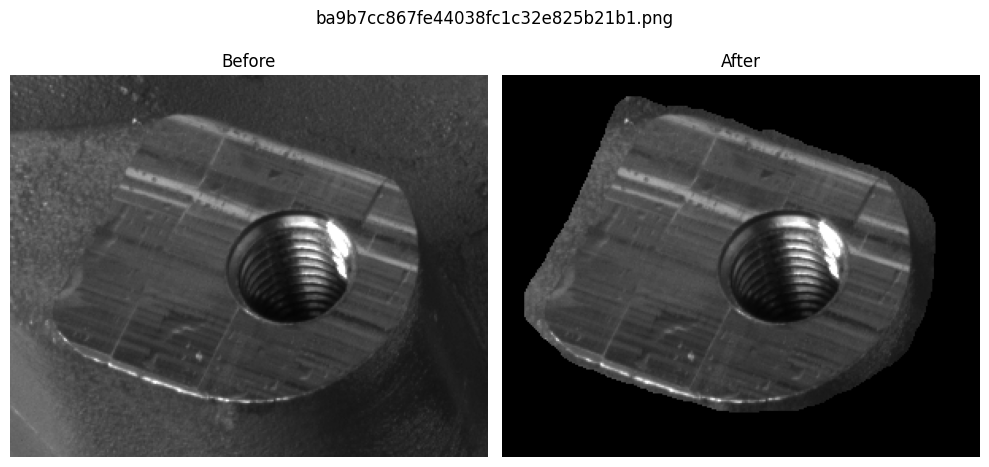

In [8]:
def show_random_before_after(src_folder, mask_bin):
    files = list(src_folder.iterdir())
    img_path = random.choice(files)
    before = Image.open(img_path).convert("RGB")
    after = apply_mask(img_path, mask_bin)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(before)
    axes[0].set_title("Before")
    axes[0].axis("off")

    axes[1].imshow(after)
    axes[1].set_title("After")
    axes[1].axis("off")

    fig.suptitle(img_path.name)
    plt.tight_layout()
    plt.show()


show_random_before_after(SRC_ROOT / "Feature 1" / "training", load_mask(SRC_ROOT / "Feature 1" / "mask.png"))

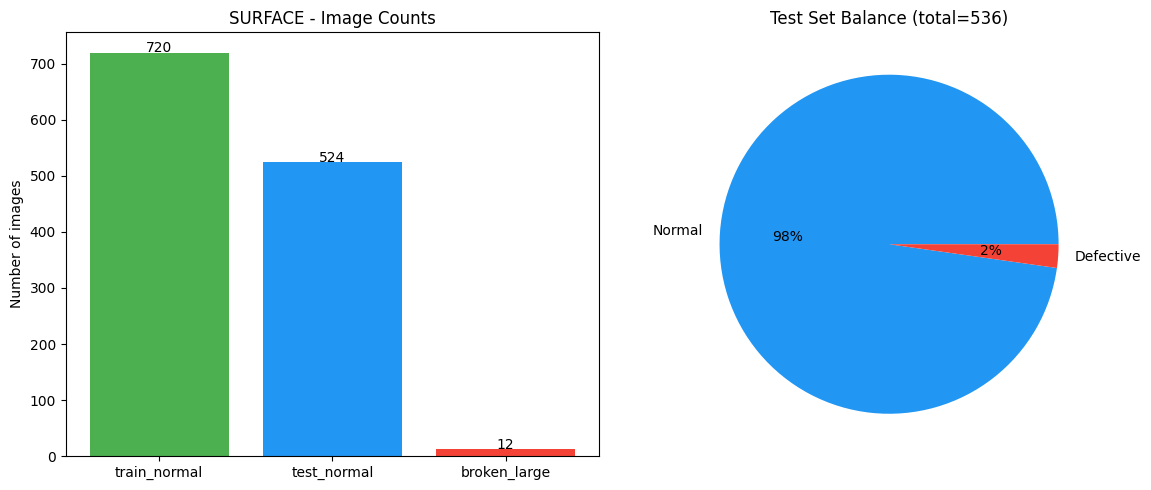

In [9]:
def analyze_category(root, category):
    cat_path = Path(root) / category
    stats = {
        "category": category,
        "train_normal": 0,
        "test_normal": 0,
        "test_defects": defaultdict(int),
        "img_size": None,
    }

    train_good = list((cat_path / "train" / "good").glob("*.png"))
    stats["train_normal"] = len(train_good)
    if train_good:
        img = Image.open(train_good[0])
        stats["img_size"] = img.size

    test_path = cat_path / "test"
    for defect_dir in sorted(test_path.iterdir()):
        if defect_dir.is_dir():
            count = len(list(defect_dir.glob("*.png")))
            if defect_dir.name == "good":
                stats["test_normal"] = count
            else:
                stats["test_defects"][defect_dir.name] = count

    return stats


def plot_category_stats(stats):
    total_test_defects = sum(stats["test_defects"].values())
    total_test = stats["test_normal"] + total_test_defects

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    labels = ["train_normal", "test_normal"] + list(stats["test_defects"].keys())
    values = [stats["train_normal"], stats["test_normal"]] + list(stats["test_defects"].values())
    colors = ["#4CAF50", "#2196F3"] + ["#F44336"] * len(stats["test_defects"])

    axes[0].bar(labels, values, color=colors)
    axes[0].set_title(f"{stats['category'].upper()} - Image Counts")
    axes[0].set_ylabel("Number of images")
    for i, v in enumerate(values):
        axes[0].text(i, v + 1, str(v), ha="center")

    axes[1].pie(
        [stats["test_normal"], total_test_defects],
        labels=["Normal", "Defective"],
        autopct="%1.0f%%",
        colors=["#2196F3", "#F44336"],
    )
    axes[1].set_title(f"Test Set Balance (total={total_test})")

    plt.tight_layout()
    plt.show()


stats = analyze_category(DATA_ROOT, CATEGORY)
plot_category_stats(stats)

In [10]:
class MVTecDataset(Dataset):
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    def __init__(self, root, category, split="train", crop_size=224, img_pad_color=0, mask_pad_color=0):
        self.root = Path(root) / category / split
        self.mask_root = Path(root) / category / "ground_truth"
        self.split = split
        self.transform = self._build_transform(crop_size, img_pad_color, normalize=True)
        self.mask_transform = self._build_transform(crop_size, mask_pad_color, normalize=False)
        self.samples = self._build_samples()
        self._print_summary(category)

    def _pad_to_square(self, img, pad_color):
        w, h = img.size
        size = max(w, h)
        new_img = Image.new(img.mode, (size, size), pad_color)
        new_img.paste(img, ((size - w) // 2, (size - h) // 2))
        return new_img

    def _build_transform(self, crop_size, pad_color, normalize):
        ops = [
            transforms.Lambda(lambda img: self._pad_to_square(img, pad_color)),
            transforms.Resize((crop_size, crop_size)),
            transforms.ToTensor(),
        ]
        if normalize:
            ops.append(transforms.Normalize(self.IMAGENET_MEAN, self.IMAGENET_STD))
        return transforms.Compose(ops)

    def _resolve_mask_path(self, class_name, img_path):
        mask_path = self.mask_root / class_name / (img_path.stem + "_mask.png")
        if not mask_path.exists():
            mask_path = self.mask_root / class_name / img_path.name
        return mask_path if mask_path.exists() else None

    def _build_samples(self):
        samples = []
        for class_dir in sorted(self.root.iterdir()):
            if not class_dir.is_dir():
                continue
            label = 0 if class_dir.name == "good" else 1
            for img_path in sorted(class_dir.glob("*.png")):
                mask_path = self._resolve_mask_path(class_dir.name, img_path) if label == 1 else None
                samples.append((img_path, mask_path, label))
        return samples

    def _print_summary(self, category):
        n_normal = sum(1 for _, _, l in self.samples if l == 0)
        n_defect = sum(1 for _, _, l in self.samples if l == 1)
        print(f"dataset '{self.split}' [{category}] : {n_normal} normal | {n_defect} defective")

    def __len__(self):
        return len(self.samples)

    def _load_mask(self, mask_path, img_t):
        if mask_path is None:
            return torch.zeros(1, img_t.shape[1], img_t.shape[2])
        mask = Image.open(mask_path).convert("L")
        mask_t = self.mask_transform(mask)
        return (mask_t > 0.5).float()

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]
        img_t = self.transform(Image.open(img_path).convert("RGB"))
        mask_t = self._load_mask(mask_path, img_t)
        return img_t, mask_t, label, str(img_path)


train_dataset = MVTecDataset(DATA_ROOT, CATEGORY, split="train", crop_size=CROP_SIZE)
test_dataset = MVTecDataset(DATA_ROOT, CATEGORY, split="test", crop_size=CROP_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"train batches: {len(train_loader)} (batch size {BATCH_SIZE})")
print(f"test batches: {len(test_loader)} (batch size {BATCH_SIZE})")

dataset 'train' [surface] : 720 normal | 0 defective
dataset 'test' [surface] : 524 normal | 12 defective
train batches: 23 (batch size 32)
test batches: 17 (batch size 32)


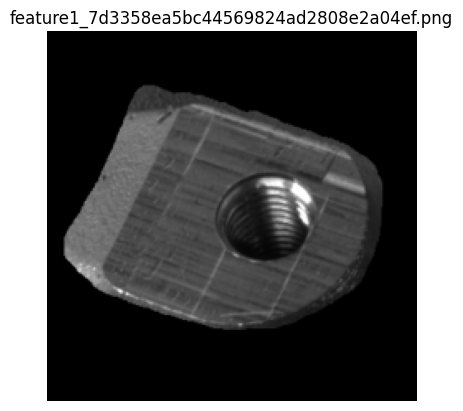

In [11]:
idx = random.randrange(len(train_dataset))
img_t, mask_t, label, path = train_dataset[idx]
img_np = img_t.permute(1, 2, 0).numpy() * np.array(train_dataset.IMAGENET_STD) + np.array(train_dataset.IMAGENET_MEAN)
img_np = np.clip(img_np, 0, 1)
plt.imshow(img_np)
plt.title(Path(path).name)
plt.axis("off")
plt.show()

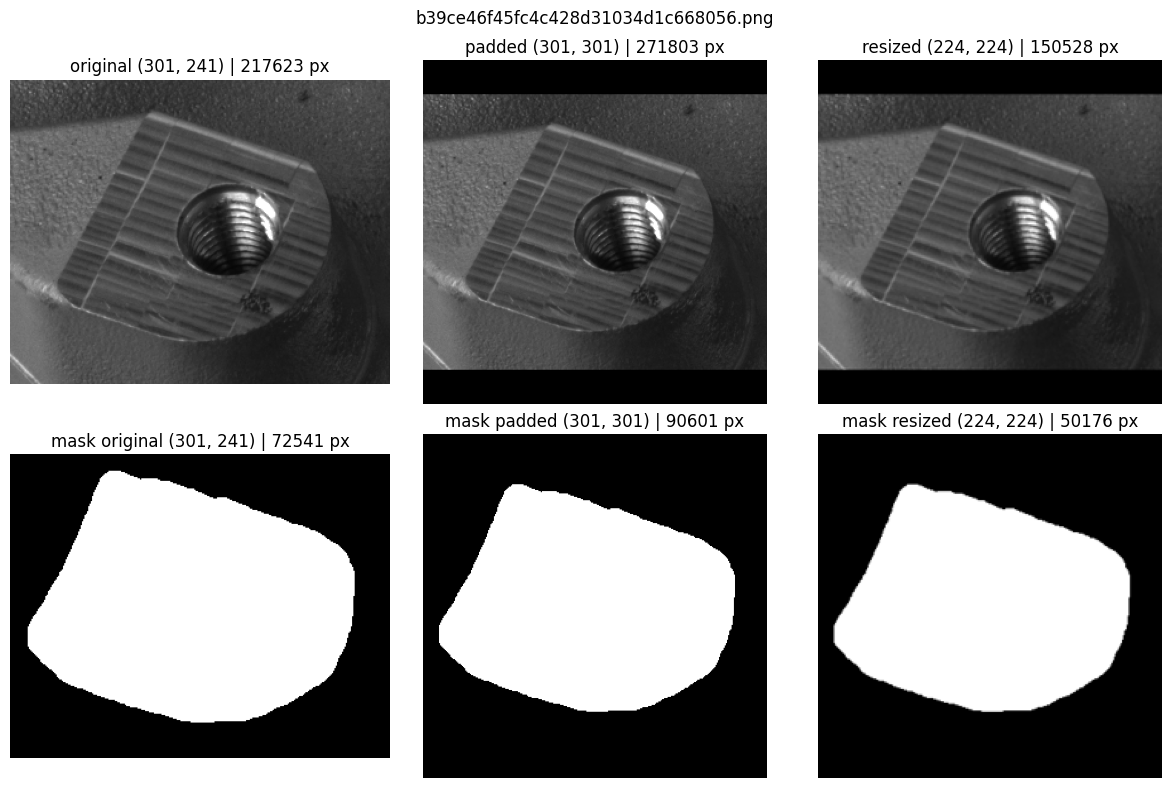

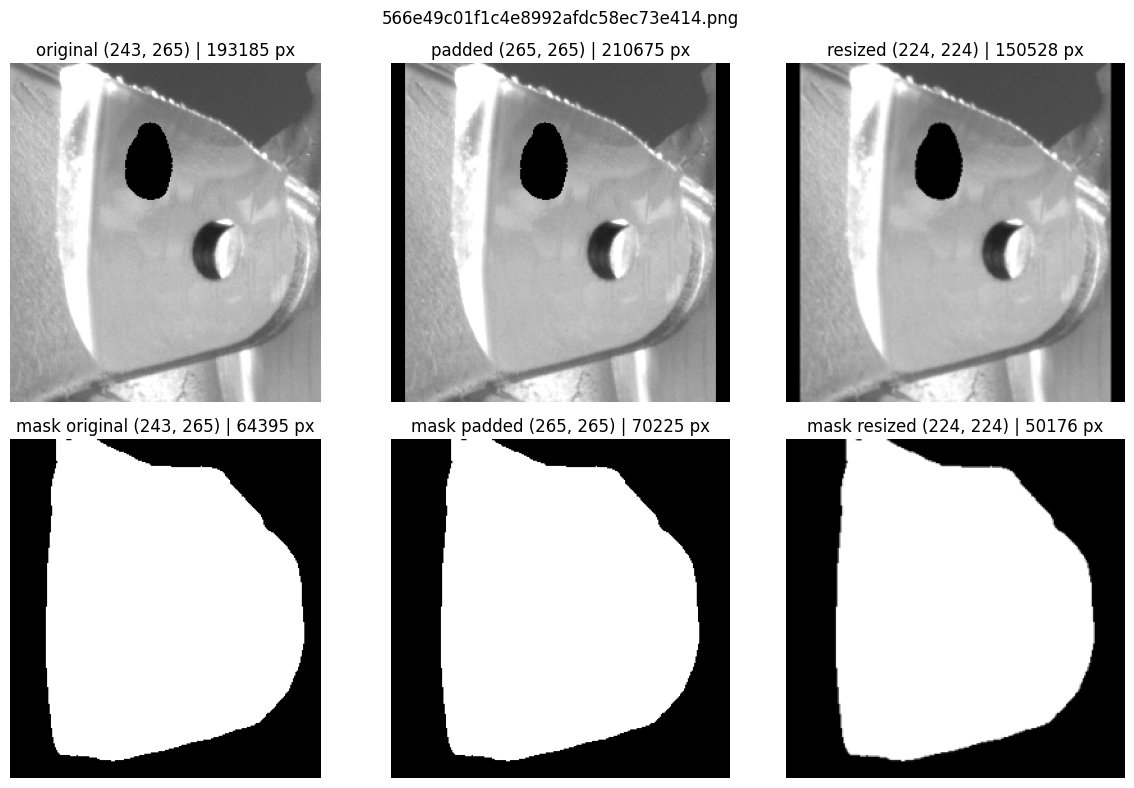

In [12]:
def visualize_padding_pipeline(img_path, mask_path, crop_size=224, img_pad_color=0, mask_pad_color=0):
    original = Image.open(img_path).convert("RGB")
    padded = train_dataset._pad_to_square(original, img_pad_color)
    resized = padded.resize((crop_size, crop_size))

    mask_original = Image.open(mask_path).convert("L")
    mask_padded = train_dataset._pad_to_square(mask_original, mask_pad_color)
    mask_resized = mask_padded.resize((crop_size, crop_size))

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    row1 = [original, padded, resized]
    row2 = [mask_original, mask_padded, mask_resized]
    titles = ["original", "padded", "resized"]

    for ax, img, title in zip(axes[0], row1, titles):
        ax.imshow(img)
        ax.set_title(f"{title} {img.size} | {np.array(img).size} px")
        ax.axis("off")

    for ax, img, title in zip(axes[1], row2, titles):
        ax.imshow(img, cmap="gray")
        ax.set_title(f"mask {title} {img.size} | {np.array(img).size} px")
        ax.axis("off")

    fig.suptitle(img_path.name)
    plt.tight_layout()
    plt.show()


feature1_sample = next((SRC_ROOT / "Feature 1" / "test_nok").iterdir())
feature1_mask = SRC_ROOT / "Feature 1" / "mask.png"
visualize_padding_pipeline(feature1_sample, feature1_mask, CROP_SIZE)

feature2_sample = next((SRC_ROOT / "Feature 2" / "test_nok").iterdir())
feature2_mask = SRC_ROOT / "Feature 2" / "mask.png"
visualize_padding_pipeline(feature2_sample, feature2_mask, CROP_SIZE)

In [13]:
class FeatureExtractor(nn.Module):
    def __init__(self, device, model_name='dinov2_vitb14'):
        super().__init__()
        self.device = device
        self.model = torch.hub.load('facebookresearch/dinov2', model_name).to(device).eval()
        for p in self.model.parameters():
            p.requires_grad = False
        self.feature_dim = self.model.embed_dim
        self.patch_size = self.model.patch_size
        print(f"{model_name} loaded")

    @torch.no_grad()
    def extract(self, imgs):
        imgs = imgs.to(self.device)
        B, C, H, W = imgs.shape
        gh, gw = H // self.patch_size, W // self.patch_size
        tokens = self.model.forward_features(imgs)['x_norm_patchtokens']
        return tokens.cpu(), (gh, gw)


extractor = FeatureExtractor(device=DEVICE, model_name='dinov2_vitb14')
sample_imgs, _, _, _ = next(iter(train_loader))
sample_patches, hw = extractor.extract(sample_imgs)
print("input images:", sample_imgs.shape)
print("patch features:", sample_patches.shape)
print(f"spatial grid: {hw[0]}x{hw[1]} = {hw[0]*hw[1]} patches per image")
print("channel dim:", sample_patches.shape[-1])

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 204MB/s]


dinov2_vitb14 loaded
input images: torch.Size([32, 3, 224, 224])
patch features: torch.Size([32, 256, 768])
spatial grid: 16x16 = 256 patches per image
channel dim: 768


In [14]:
# class FeatureExtractor(nn.Module):
#     def __init__(self, device, neighbourhood_size=3):
#         super().__init__()
#         self.device = device
#         self.p = neighbourhood_size
#         backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
#         self.extractor = create_feature_extractor(
#             backbone,
#             return_nodes={
#                 "features.4": "layer2",
#                 "features.6": "layer3",
#             },
#         )
#         self.extractor = self.extractor.to(device).eval()
#         for param in self.extractor.parameters():
#             param.requires_grad = False
#         print("efficientnet-b4 loaded")

#     def _neighbourhood_pooling(self, feature_map):
#         if self.p <= 1:
#             return feature_map
#         pad = self.p // 2
#         return F.avg_pool2d(feature_map, kernel_size=self.p, stride=1, padding=pad)

#     def _combine_layers(self, f2, f3):
#         f2 = self._neighbourhood_pooling(f2)
#         f3 = self._neighbourhood_pooling(f3)
#         f3_up = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
#         return torch.cat([f2, f3_up], dim=1)

#     @torch.no_grad()
#     def extract(self, imgs):
#         imgs = imgs.to(self.device)
#         feats = self.extractor(imgs)
#         combined = self._combine_layers(feats["layer2"], feats["layer3"])
#         B, C, H, W = combined.shape
#         patches = combined.permute(0, 2, 3, 1).reshape(B, H * W, C)
#         return patches.cpu(), (H, W)


# extractor = FeatureExtractor(device=DEVICE, neighbourhood_size=3)
# sample_imgs, _, _, _ = next(iter(train_loader))
# sample_patches, hw = extractor.extract(sample_imgs)

# print("input images:", sample_imgs.shape)
# print("patch features:", sample_patches.shape)
# print(f"spatial grid: {hw[0]}x{hw[1]} = {hw[0]*hw[1]} patches per image")
# print("channel dim:", sample_patches.shape[-1], "(layer2 + layer3 concatenated)")

In [15]:
SEED = 42

class PatchCore:
    def __init__(self, coreset_ratio=0.10, n_neighbors=9, device='cuda'):
        self.coreset_ratio = coreset_ratio
        self.n_neighbors = n_neighbors
        self.device = device
        self.memory_bank = None
        self.hw_shape = None

    def fit(self, all_patches, hw_shape):
        self.hw_shape = hw_shape
        feats = all_patches if isinstance(all_patches, torch.Tensor) else torch.from_numpy(all_patches)
        print(f"initial memory bank: {len(feats):,} vectors, dim {feats.shape[1]}")
        n_keep = max(1, int(len(feats) * self.coreset_ratio))
        print(f"applying coreset (ratio={self.coreset_ratio*100:.0f}%), keeping {n_keep:,} vectors")
        selected_idx = self._greedy_coreset(feats, n_keep)
        self.memory_bank = feats[selected_idx].to(self.device)
        print(f"final memory bank: {len(self.memory_bank):,} vectors")
        print(f"reduction: {len(feats)/len(self.memory_bank):.0f}x fewer vectors")

    def _greedy_coreset(self, feats, n_keep):
        rng = np.random.default_rng(SEED)
        selected = rng.choice(len(feats), size=n_keep, replace=False)
        print(f"  Coreset : Random sampling {n_keep}/{len(feats)} vectors selected.")
        return selected

    def _to_tensor(self, patch_features):
        if isinstance(patch_features, np.ndarray):
            return torch.from_numpy(patch_features)
        return patch_features

    def _compute_patch_scores(self, patch_features):
        x = self._to_tensor(patch_features).to(self.device)
        dists = torch.cdist(x, self.memory_bank)
        knn_dists, _ = torch.topk(dists, self.n_neighbors, dim=1, largest=False)
        return knn_dists[:, 0].cpu().numpy()

    def score_image(self, patch_features):
        scores = self._compute_patch_scores(patch_features)
        return float(scores.max())

    def score_map(self, patch_features):
        H, W = self.hw_shape
        scores = self._compute_patch_scores(patch_features).reshape(H, W)
        scores_up = cv2.resize(scores, (224, 224), interpolation=cv2.INTER_LINEAR)
        return gaussian_filter(scores_up, sigma=4)

In [16]:
%%time
def extract_all_patches(loader, extractor, log_every=5):
    all_patches = []
    hw_shape = None
    for batch_idx, (imgs, _, _, _) in enumerate(loader):
        patches, hw = extractor.extract(imgs)
        hw_shape = hw
        B, HW, C = patches.shape
        all_patches.append(patches.reshape(-1, C))
        if batch_idx % log_every == 0:
            print(f"batch {batch_idx+1}/{len(loader)} extracted")
    return torch.cat(all_patches, dim=0), hw_shape


print(f"feature extraction - {CATEGORY} - train")
all_train_patches, hw_shape = extract_all_patches(train_loader, extractor)

print("n images:", len(train_dataset))
print(f"patches/image: {hw_shape[0]*hw_shape[1]} ({hw_shape[0]}x{hw_shape[1]})")
print(f"total patches: {len(all_train_patches):,}")
print("channel dim:", all_train_patches.shape[1])

feature extraction - surface - train
batch 1/23 extracted
batch 6/23 extracted
batch 11/23 extracted
batch 16/23 extracted
batch 21/23 extracted
n images: 720
patches/image: 256 (16x16)
total patches: 184,320
channel dim: 768
CPU times: user 10.1 s, sys: 946 ms, total: 11.1 s
Wall time: 10.8 s


In [17]:
%%time
model = PatchCore(coreset_ratio=CORESET_RATIO, n_neighbors=N_NEIGHBORS)
model.fit(all_train_patches, hw_shape)

with open(f'patchcore_{CATEGORY}.pkl', 'wb') as f:
    pickle.dump(model, f)

initial memory bank: 184,320 vectors, dim 768
applying coreset (ratio=15%), keeping 27,648 vectors
  Coreset : Random sampling 27648/184320 vectors selected.
final memory bank: 27,648 vectors
reduction: 7x fewer vectors
CPU times: user 134 ms, sys: 194 ms, total: 328 ms
Wall time: 272 ms


In [18]:
%%time
from tqdm import tqdm

def compute_image_scores(loader, extractor, model):
    scores = []
    for imgs, _, _, _ in tqdm(loader, desc="scoring"):
        patches, hw = extractor.extract(imgs)
        B, HW, C = patches.shape
        for i in range(B):
            scores.append(model.score_image(patches[i].numpy()))
    return scores

train_scores = compute_image_scores(train_loader, extractor, model)
threshold = np.percentile(train_scores, THRESHOLD_PCT)

print(f"train scores - min: {min(train_scores):.4f} | max: {max(train_scores):.4f}")
print(f"threshold (percentile {THRESHOLD_PCT}): {threshold:.4f}")

scoring: 100%|██████████| 23/23 [00:15<00:00,  1.46it/s]

train scores - min: 21.2219 | max: 43.8941
threshold (percentile 99): 36.0894
CPU times: user 15.4 s, sys: 378 ms, total: 15.8 s
Wall time: 15.8 s


In [19]:
%%time
from tqdm import tqdm

def collect_predictions(loader, extractor, model):
    scores, labels, paths = [], [], []
    score_maps, masks_list = [], []
    for imgs, masks, lbls, pths in tqdm(loader, desc="evaluating"):
        patches, hw = extractor.extract(imgs)
        B, HW, C = patches.shape
        for i in range(B):
            patch_i = patches[i].numpy()
            scores.append(model.score_image(patch_i))
            score_maps.append(model.score_map(patch_i))
            labels.append(lbls[i].item())
            paths.append(pths[i])
            masks_list.append(masks[i, 0].numpy())
    return np.array(scores), np.array(labels), paths, score_maps, masks_list

def compute_metrics(scores, labels, score_maps, masks_list, threshold):
    auroc_image = roc_auc_score(labels, scores)
    gt_flat = np.concatenate([m.flatten() for m in masks_list])
    pred_flat = np.concatenate([s.flatten() for s in score_maps])
    auroc_pixel = roc_auc_score((gt_flat > 0.5).astype(int), pred_flat)
    preds_binary = (scores > threshold).astype(int)
    f1 = f1_score(labels, preds_binary, zero_division=0)
    return auroc_image, auroc_pixel, f1

def print_results(category, auroc_image, auroc_pixel, f1, threshold):
    print(f"results - {category.upper()}")
    print(f"auroc image-level: {auroc_image:.4f} ({auroc_image*100:.1f}%)")
    print(f"auroc pixel-level: {auroc_pixel:.4f} ({auroc_pixel*100:.1f}%)")
    print(f"threshold used: {threshold:.4f}")
    print("paper target: auroc image > 98%")

test_scores, test_labels, test_paths, all_score_maps, all_masks = collect_predictions(test_loader, extractor, model)
auroc_image, auroc_pixel, f1 = compute_metrics(test_scores, test_labels, all_score_maps, all_masks, threshold)
print_results(CATEGORY, auroc_image, auroc_pixel, f1, threshold)

evaluating: 100%|██████████| 17/17 [00:16<00:00,  1.02it/s]


results - SURFACE
auroc image-level: 0.9981 (99.8%)
auroc pixel-level: 0.8898 (89.0%)
threshold used: 36.0894
paper target: auroc image > 98%
CPU times: user 23.7 s, sys: 2.07 s, total: 25.8 s
Wall time: 25.9 s


In [20]:
from sklearn.metrics import fbeta_score

def find_threshold_for_recall(scores, labels, target_recall=1.0):
    thresholds = np.sort(scores)
    for t in thresholds:
        preds = (scores > t).astype(int)
        tp = ((preds == 1) & (labels == 1)).sum()
        fn = ((preds == 0) & (labels == 1)).sum()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        if recall >= target_recall:
            best_t = t
    return best_t

recall_threshold = find_threshold_for_recall(test_scores, test_labels, target_recall=1.0)
preds_binary = (test_scores > recall_threshold).astype(int)
f1_recall = f1_score(test_labels, preds_binary, zero_division=0)
f2_recall = fbeta_score(test_labels, preds_binary, beta=2, zero_division=0)

print("recall threshold:", recall_threshold)
print("f2 at this threshold:", f2_recall)

recall threshold: 36.90513229370117
f2 at this threshold: 0.9375


In [21]:
import time
import random

def measure_inference_time(dataset, extractor, model, device, n_warmup=5, n_samples=10):
    indices = random.sample(range(len(dataset)), n_samples)
    samples = [dataset[i][0].unsqueeze(0) for i in indices]
    extractor.model = extractor.model.to(device)
    extractor.device = device
    for i in range(n_warmup):
        img = samples[i % len(samples)]
        patches, hw = extractor.extract(img)
        _ = model.score_image(patches[0])
    times = []
    for img in samples:
        start = time.perf_counter()
        patches, hw = extractor.extract(img)
        _ = model.score_image(patches[0])
        end = time.perf_counter()
        times.append(end - start)
    return np.array(times)


def summarize_times(gpu_times, cpu_times):
    df = pd.DataFrame({
        "device": ["gpu", "cpu"],
        "mean_ms": [gpu_times.mean()*1000, cpu_times.mean()*1000],
        "std_ms": [gpu_times.std()*1000, cpu_times.std()*1000],
        "min_ms": [gpu_times.min()*1000, cpu_times.min()*1000],
        "max_ms": [gpu_times.max()*1000, cpu_times.max()*1000],
    })
    return df


gpu_times = measure_inference_time(test_dataset, extractor, model, device=torch.device("cuda"))
cpu_times = measure_inference_time(test_dataset, extractor, model, device=torch.device("cpu"))

summary_df = summarize_times(gpu_times, cpu_times)
summary_df

,device,mean_ms,std_ms,min_ms,max_ms
0,gpu,28.939141,0.825168,27.282844,29.783249
1,cpu,295.213271,6.228081,286.328352,306.656338


# Confusion matrix

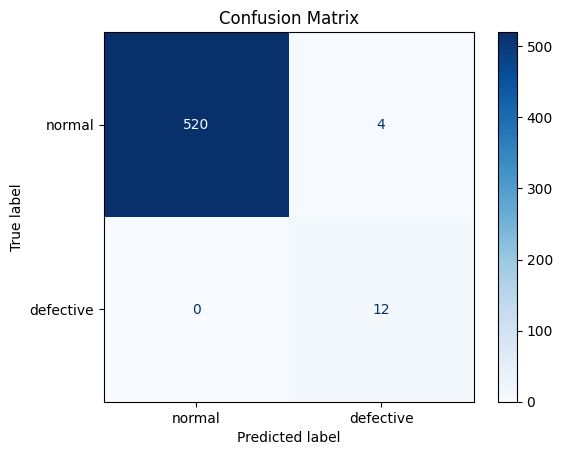

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def report_predictions(scores, labels, paths, threshold):
    preds = (scores > threshold).astype(int)
    for p, l, path in zip(preds, labels, paths):
        if p == 1:
            status = "correct" if l == 1 else "false alarm"
    return preds

def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["normal", "defective"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix")
    plt.show()

preds_recall = report_predictions(test_scores, test_labels, test_paths, recall_threshold)
plot_confusion_matrix(test_labels, preds_recall)

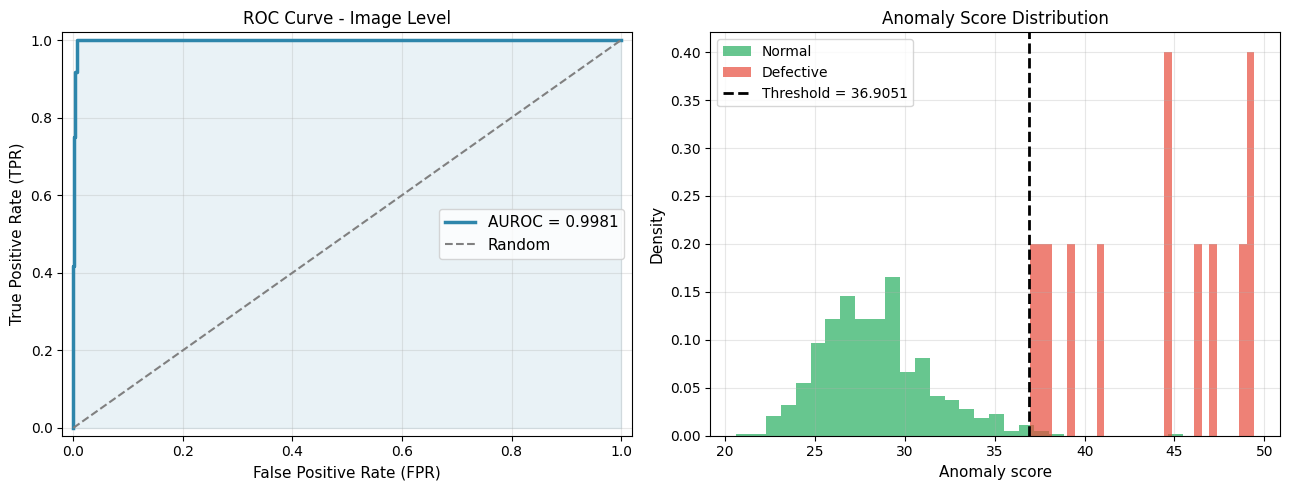

In [23]:
def plot_roc_curve(ax, fpr, tpr, auroc_image):
    ax.plot(fpr, tpr, color="#2E86AB", lw=2.5, label=f"AUROC = {auroc_image:.4f}")
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1.5, label="Random")
    ax.fill_between(fpr, tpr, alpha=0.1, color="#2E86AB")
    ax.set_xlabel("False Positive Rate (FPR)", fontsize=11)
    ax.set_ylabel("True Positive Rate (TPR)", fontsize=11)
    ax.set_title("ROC Curve - Image Level", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])


def plot_score_distribution(ax, test_scores, test_labels, threshold):
    normal_scores = test_scores[test_labels == 0]
    defect_scores = test_scores[test_labels == 1]
    ax.hist(normal_scores, bins=30, alpha=0.7, color="#27AE60", label="Normal", density=True)
    ax.hist(defect_scores, bins=30, alpha=0.7, color="#E74C3C", label="Defective", density=True)
    ax.axvline(threshold, color="black", lw=2, linestyle="--", label=f"Threshold = {threshold:.4f}")
    ax.set_xlabel("Anomaly score", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title("Anomaly Score Distribution", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)


def plot_evaluation(test_scores, test_labels, auroc_image, threshold, category):
    fpr, tpr, thresholds_roc = roc_curve(test_labels, test_scores)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    plot_roc_curve(axes[0], fpr, tpr, auroc_image)
    plot_score_distribution(axes[1], test_scores, test_labels, threshold)

    plt.tight_layout()
    plt.savefig("evaluation_roc.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_evaluation(test_scores, test_labels, auroc_image, recall_threshold, CATEGORY)

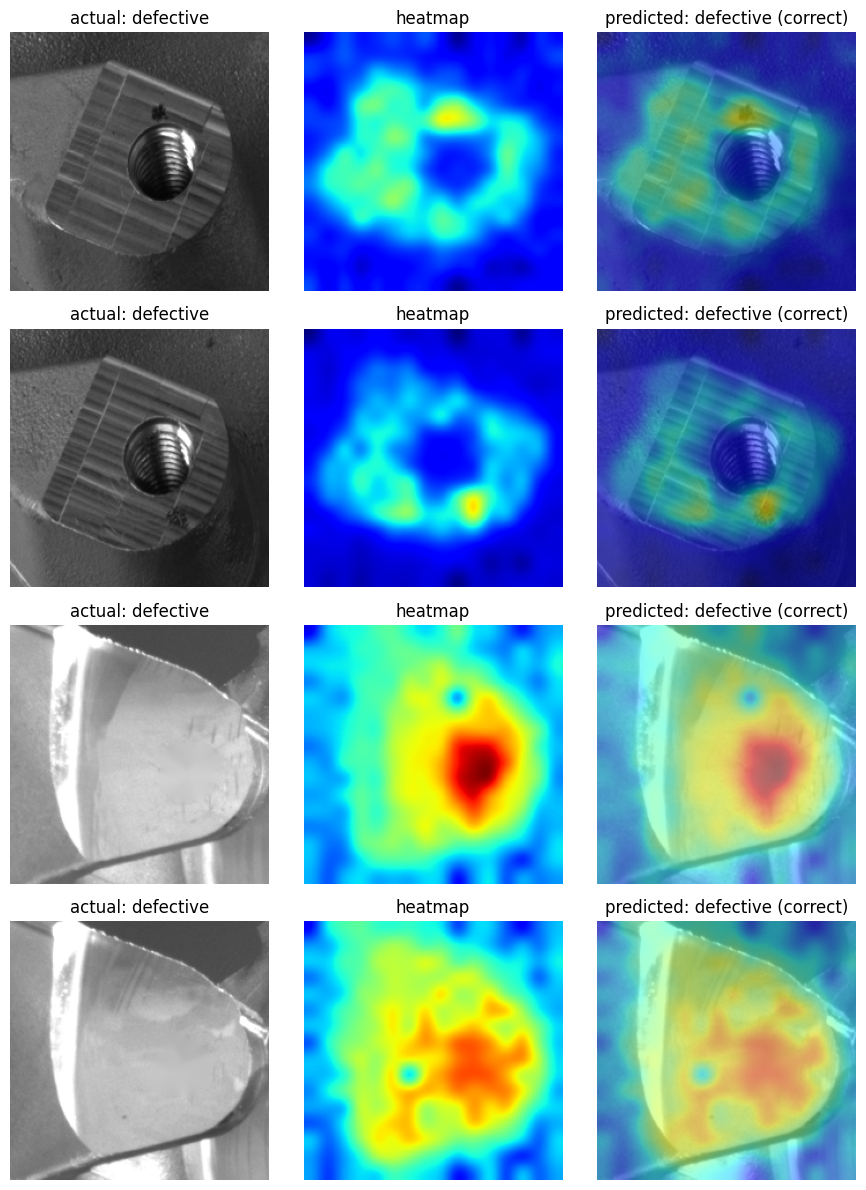

In [24]:
def get_unmasked_path(masked_path):
    parts = Path(masked_path).parts
    idx = parts.index(CATEGORY)
    sub_parts = parts[idx + 1:]
    filename = sub_parts[-1]

    prefix, _, orig_name = filename.partition("_")
    feature = "Feature 1" if prefix == "feature1" else "Feature 2"
    src = SRC_ROOT / feature

    if sub_parts[0] == "train":
        return src / "training" / orig_name
    if sub_parts[1] == "good":
        return src / "test_ok" / orig_name
    return src / "test_nok" / orig_name

def visualize_heatmaps(loader, extractor, model, threshold, n_samples=4, vmin=None, vmax=None):
    imgs, masks, labels, paths = next(iter(loader))
    patches, hw = extractor.extract(imgs)
    B = imgs.shape[0]
    n_samples = min(n_samples, B)

    all_maps = [model.score_map(patches[i].numpy()) for i in range(n_samples)]
    if vmin is None:
        vmin = min(m.min() for m in all_maps)
    if vmax is None:
        vmax = max(m.max() for m in all_maps)

    fig, axes = plt.subplots(n_samples, 3, figsize=(9, 3 * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, 3)

    for i in range(n_samples):
        raw_path = get_unmasked_path(paths[i])
        raw_img = Image.open(raw_path).convert("RGB").resize((224, 224))
        img_np = np.array(raw_img) / 255.0

        smap = all_maps[i]
        score = model.score_image(patches[i].numpy())
        actual_label = labels[i].item()
        actual = "defective" if actual_label == 1 else "non defective"
        pred_label = 1 if score > threshold else 0
        predicted = "defective" if pred_label == 1 else "non defective"
        correct = "correct" if pred_label == actual_label else "incorrect"

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"actual: {actual}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(smap, cmap="jet", vmin=vmin, vmax=vmax)
        axes[i, 1].set_title("heatmap")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(img_np)
        axes[i, 2].imshow(smap, cmap="jet", alpha=0.5, vmin=vmin, vmax=vmax)
        axes[i, 2].set_title(f"predicted: {predicted} ({correct})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


visualize_heatmaps(test_loader, extractor, model, recall_threshold, n_samples=4)

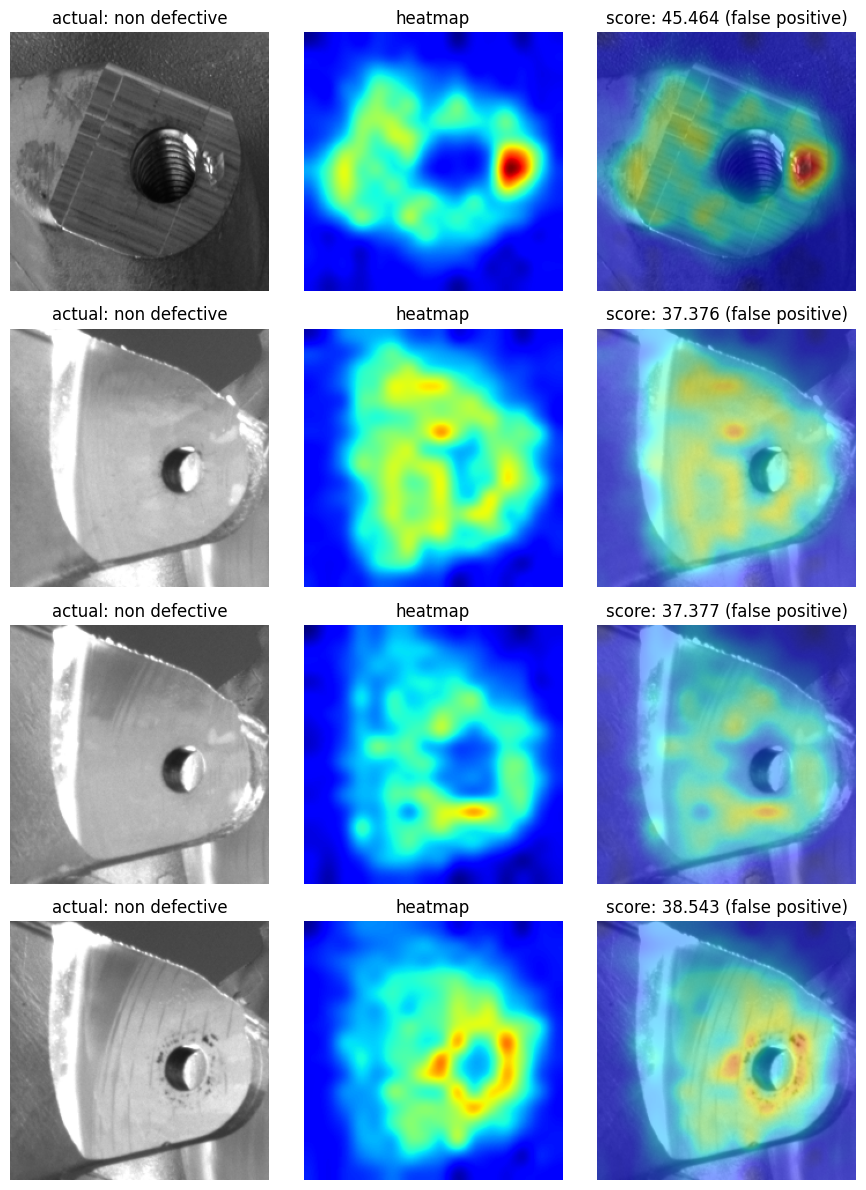

total false positives: 4


In [25]:
def visualize_false_positives(paths, scores, labels, score_maps, threshold, max_samples=None, vmin=None, vmax=None):
    fp_idx = [i for i in range(len(labels)) if labels[i] == 0 and scores[i] > threshold]
    if not fp_idx:
        print("no false positives")
        return
    if max_samples:
        fp_idx = fp_idx[:max_samples]
    n = len(fp_idx)
    fp_maps = [score_maps[i] for i in fp_idx]
    if vmin is None:
        vmin = min(m.min() for m in fp_maps)
    if vmax is None:
        vmax = max(m.max() for m in fp_maps)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = axes.reshape(1, 3)
    for row, i in enumerate(fp_idx):
        raw_path = get_unmasked_path(paths[i])
        raw_img = Image.open(raw_path).convert("RGB").resize((224, 224))
        img_np = np.array(raw_img) / 255.0
        smap = score_maps[i]
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title("actual: non defective")
        axes[row, 0].axis("off")
        axes[row, 1].imshow(smap, cmap="jet", vmin=vmin, vmax=vmax)
        axes[row, 1].set_title("heatmap")
        axes[row, 1].axis("off")
        axes[row, 2].imshow(img_np)
        axes[row, 2].imshow(smap, cmap="jet", alpha=0.5, vmin=vmin, vmax=vmax)
        axes[row, 2].set_title(f"score: {scores[i]:.3f} (false positive)")
        axes[row, 2].axis("off")
    plt.tight_layout()
    plt.show()
    print(f"total false positives: {n}")

visualize_false_positives(test_paths, test_scores, test_labels, all_score_maps, recall_threshold)

In [26]:
end_time = datetime.now()
duration = (end_time - start_time).total_seconds() / 60
print(f"Duration: {duration:.2f} minutes")

Duration: 2.16 minutes
